# Decomposing Fairness Failures: Evaluating Structural and Algorithmic Bias through Canadian Income Prediction

---

**Introduction** 

In implementing responsible AI, developers have an obligation to hold models accountable in data analysis and findings potentially influenced by biases, circumstances, and fairness (or lack thereof). The analysis below uses a Canadian income survey dataset (Hirapara, 2025) to predict individuals' total incomes to determine whether inferences indicate bias in their results; consequently, this leads to a deeper question: 

**How might we determine structural inequality in data and/or a model so we might differentiate structural versus algorithmic biases and use appropriate mitigation techniques?**

Using a Random Forest Regressor, the analysis below attempts to predict total income from three features: (1) the province of residence, (2), the highest education level earned, and (3) the work reference (i.e., employed, unemployed, or retired). The dataset was preprocessed by selecting these columns explicitly, and an 80/20 train-test split was applied before training took place. After applying a baseline evaluation with MAE and R², I chose to retrain the model using inverse-frequency sample weights by province and compare baseline and mitigated disparity scores across all three features; consequently, the model is told to pay more attention to underrepresented groups during training. Since the resulting analysis did not change the model's outputs, the model is showing that it is considering underrepresented groups but requires more information. As these features were selected deliberately to avoid sensitive data, the model is preserving fairness where possible, but this does not imply the model's results are fair.

Looking at the final results, the means of actual and predicted incomes are close, as they are within `$500` (`$111,127` versus `$111,443`). This is, however, misleading as the MAE is `$52,880` and median error is 40%. The model is inaccurate at the individual level, and it predits the average by chance by overcorrecting in both directions (as seen in the Shap analysis and final findings). For the low income earners in the dataset, the model predicts approximately `$94,000` for total income whereas the dataset has an average of `$35,000`; this is a 161% error and indicates overprediction. For the high income earners, the model's results show an average of `$125,000` while the dataset shows `$218,000`; this reveals underprediction. The distributional unfairness would not showcase the edgecases of income earners accurately, despite being reliable for middle income earners. 

What does this mean? In returning to the key question of differentiating between structural versus algorithmic fairness, there are a few key considerations for models like this one. Firstly, mitigation does not affect the data when the information provided to a model is not sufficient to properly make analysis-based decisions. This is structural versus algorithmic, which means more data is needed when sensitive data is permissible to use and responsibly used for analysis. Secondly, the low income earner overprediction is not due to the model but the same need for more information for edgecases, so the model would benefit from having more data on groups which show more variability to determine whether that is truly accurate. Lastly, the features selected for this analysis are important, because they consider how, from an administrative perspective, income earners would be perceived. In reality, people experience income in different ways, so an analysis like this one should not be used in isolation based on this third indication of structural bias.

Overall, this exploration reveals that establishing baseline disparity can reveal structural versus algorithmic biases to make sure that, for all datasets and edgecases within, populations are adequately represented in data and by models.

---

**Table of Contents:**

0  | Prepare with Installations <br>
1  | Load and Inspect Data <br>
2  | Clean and Preprocess Data <br>
3  | Train Random Forest Regressor <br>
4  | Fairness Audit - Performance Parity Across Groups <br>
5  | Visualization - Fairness Disparity Plots <br>
6  | Feature Importance <br>
7  | Shap Explainability <br>
8  | Fairness Summary <br>
9  | Mitigation - Reweighing Columns <br>
10 | Final Findings <br>

---

**Note from the Author:**

As a Canadian, this project is close to my heart, as I wanted to perform this analysis on a Canadian dataset. Thank you for viewing this project.

---

In [184]:
'''
==========================================================================
Project: Evaluating Fairness in Public Transfer Programs
Dataset: Income Survey | Finance Analysis (Kaggle)
Author: Chloe Robillard
==========================================================================
0 | Prepare with Installations
==========================================================================
'''

# Importing necessary libraries:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Adding an exception for shap installation:

try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False
    print("Shap library not installed. Run 'pip install shap' for explainability analysis (Section 7).")

In [185]:
'''
==========================================================================
1 | Load and Inspect Data
==========================================================================
'''

# Creating the database:

df = pd.read_csv("Income Survey Dataset.csv")

print(f"Shape: {df.shape}")

Shape: (72643, 38)


In [186]:
'''
==========================================================================
2 | Clean and Preprocess Data
==========================================================================
'''

# Processing the data for analysis:

columns = df[["Province", "Highest_edu", "Work_ref"]]

target_col = "Total_income"

df = columns.copy()
df[target_col] = pd.read_csv("Income Survey Dataset.csv")[target_col]

df.dropna(subset = [target_col], inplace = True)

# Setting the columns to be analyzed:

fairness_axes = {"province": "Province", "education": "Highest_edu", "employment_type": "Work_ref"}

categorical_cols = df.select_dtypes(include = ["object"]).columns.tolist()
le = LabelEncoder()
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")
    df[col] = le.fit_tranform(df[col].astype(str))
    
df.fillna(df.median(numeric_only = True), inplace = True)

# Showcasing the volume of data to be analyzed:

print(f"Processed Shape: {df.shape}")
    
print(f"\nColumn Names:\n {columns}")

Processed Shape: (72643, 4)

Column Names:
        Province  Highest_edu  Work_ref
0            59            3         2
1            35            2         1
2            35            3         1
3            35            1         1
4            35            6         6
...         ...          ...       ...
72638        35            2         1
72639        24            3         1
72640        24            3         2
72641        24            2         2
72642        24            1         2

[72643 rows x 3 columns]


In [187]:
'''
==========================================================================
3 | Train Random Forest Regressor
==========================================================================
'''

# Training the model to be used for analysis on the processed data:

X = df.drop(columns = [target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model = RandomForestRegressor(n_estimators = 100, random_state = 42, n_jobs = -1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Printing the model's baseline performance statistics:

print("\n=== Baseline Model Performance ===")
print(f"MAE: {mean_absolute_error(y_test, y_pred):,.2f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")


=== Baseline Model Performance ===
MAE: 52,880.67
R²: 0.1200


In [188]:
'''
==========================================================================
4 | Fairness Audit - Performance Parity Across Groups
==========================================================================
'''

# Setting the metrics for the fairness audit:

test_df = X_test.copy()
test_df["actual"] = y_test.values
test_df["predicted"] = y_pred
test_df["abs_error"] = (test_df["actual"] - test_df["predicted"]).abs()

fairness_results = {}

print("\n=== Fairness Audit: MAE by Group ===")

for axis_label, col in fairness_axes.items():
    if col not in test_df.columns:
        print(f"Column '{col}' not found - update fairness_axes mapping.")
        continue
    
    # Calculating and printing the disparity of the model's accuracy (i.e., how far the predictions are on average):
    
    group_mae = test_df.groupby(col)["abs_error"].mean().sort_values()
    disparity = group_mae.max() - group_mae.min()
    fairness_results[axis_label] = group_mae
    
    print(f"\n {axis_label.upper()} (disparity = {disparity:,.2f})):")
    print(group_mae.to_string())


=== Fairness Audit: MAE by Group ===

 PROVINCE (disparity = 26,788.24)):
Province
13    41108.374439
12    42652.045125
11    42743.988971
10    47766.408311
24    48139.346102
46    50488.530243
47    51448.241071
59    53131.680581
35    57271.941505
48    67896.616362

 EDUCATION (disparity = 26,454.26)):
Highest_edu
1    41018.887289
9    45643.133397
3    47421.558372
2    51451.652991
6    54181.506259
4    67473.147899

 EMPLOYMENT_TYPE (disparity = 18,573.08)):
Work_ref
2    40372.783733
6    54181.506259
1    58945.863918


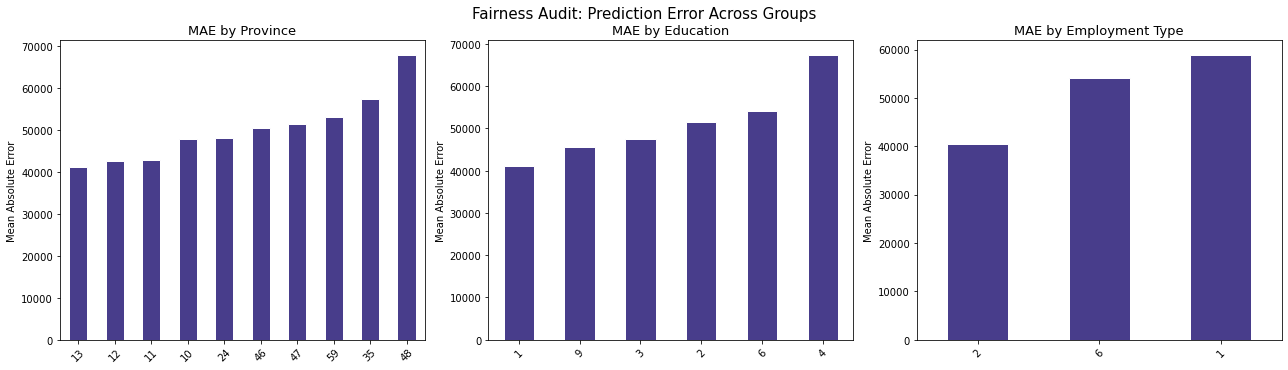

In [189]:
'''
==========================================================================
5 | Visualization - Fairness Disparity Plots
==========================================================================
'''

# Creating subplots to visualize disparity in the model's analysis by the three fairness axes (i.e., province, education, and employment type):

fig, axes = plt.subplots(1, len(fairness_results), figsize = (6 * len(fairness_results), 5))

if len(fairness_results) == 1:
    axes = [axes]
    
for ax, (axis_label, group_mae) in zip(axes, fairness_results.items()):
    group_mae.plot(kind = "bar", ax = ax, color = "darkslateblue", edgecolor = "white")
    ax.set_title(f"MAE by {axis_label.replace('_', ' ').title()}", fontsize = 13)
    ax.set_xlabel("")
    ax.set_ylabel("Mean Absolute Error")
    ax.tick_params(axis = "x", rotation = 45)
    
plt.suptitle("Fairness Audit: Prediction Error Across Groups", fontsize = 15, y = 1.02)
plt.tight_layout()
plt.savefig("fairness_disparity.png", dpi = 150, bbox_inches = "tight")
plt.show()

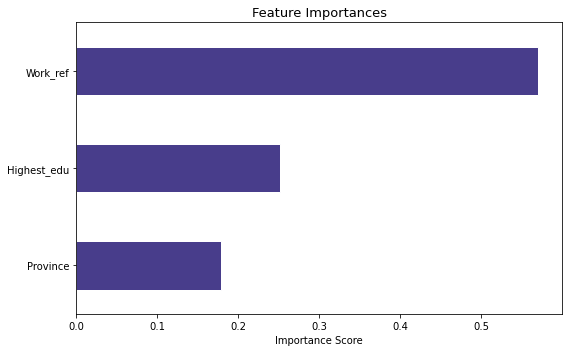

In [208]:
'''
==========================================================================
6 | Feature Importance
--------------------------------------------------------------------------
    Which transfer programs drive predictions?
==========================================================================
'''

# Setting the importances variable to calculate reliance on the three key features of the model:

importances = pd.Series(model.feature_importances_, index = X.columns)
top_features = importances.nlargest(3)

plt.figure(figsize = (8,5))
top_features.sort_values().plot(kind = "barh", color = "darkslateblue", edgecolor = "white")
plt.title("Feature Importances", fontsize = 13)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi = 150, bbox_inches = "tight")
plt.show()


Running Shap analysis...
...loading...


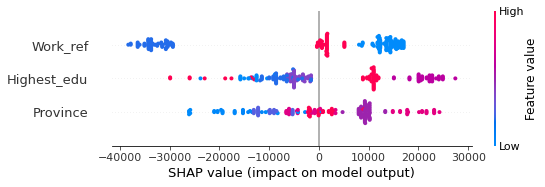

Analysis complete.


In [191]:
'''
==========================================================================
7 | Shap Explainability
--------------------------------------------------------------------------
    Note: This part of the analysis is conditional on the library being 
    installed.
==========================================================================
'''

# Creating the Shap analysis for how features impact predictions:

if shap_available:
    print("\nRunning Shap analysis...")
    print("...loading...")
    
    # Plotting how the results are pushed based on the features:
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test.iloc[:200])
    
    plt.figure()
    shap.summary_plot(shap_values, X_test.iloc[:200], show = False)
    plt.tight_layout()
    plt.savefig("shap_summary.png", dpi = 150, bbox_inches = "tight")
    plt.show()
    print("Analysis complete.")

In [192]:
'''
==========================================================================
8 | Fairness Summary
==========================================================================
'''

# Summarizing the MAEs and disparities by feature:

summary_rows = []

for axis_label, group_mae in fairness_results.items():
    summary_rows.append({
        "Fairness Axis": axis_label,
        "Best Group MAE": group_mae.min(),
        "Worst Group MAE": group_mae.max(),
        "Disparity": group_mae.max() - group_mae.min(),
        "Disparity %": f"{(group_mae.max() - group_mae.min()) / group_mae.min() * 100:.1f}%"
    })
    
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index = False))

   Fairness Axis  Best Group MAE  Worst Group MAE     Disparity Disparity %
        province    41108.374439     67896.616362  26788.241923       65.2%
       education    41018.887289     67473.147899  26454.260610       64.5%
 employment_type    40372.783733     58945.863918  18573.080185       46.0%



=== Mitigation: Reweighing ===

Baseline - MAE: 52,880.67 | R²: 0.1200
Mitigated - MAE: 52,880.67 | R²: 0.1200


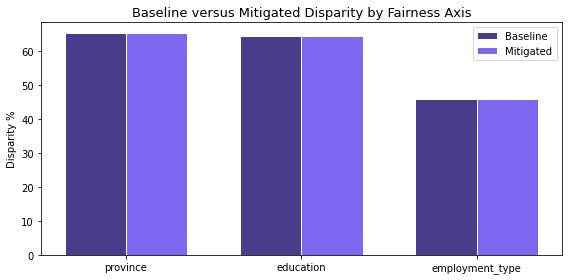


Disparity Comparison (Baseline versus Mitigated):
   Fairness Axis Baseline Disparity % Mitigated Disparity % Change Improved
        province                65.2%                 65.2%   +0.0        ✕
       education                64.5%                 64.5%   -0.0        ✕
 employment_type                46.0%                 46.0%   -0.0        ✕


In [214]:
'''
==========================================================================
9 | Mitigation - Reweighing Columns
--------------------------------------------------------------------------
    Assigning sample weights inversely proportional to group size within
    each fairness axis to retrain and encourage the model to pay more 
    attention to harder-to-predict groups.
    
    Honest Limitations:
    
    Reweighing is a preprocessing mitigation and may reduce disparity on 
    the primary axis while shifting it.
    
    This dataset reflects historical patterns, and the model may encode 
    structural inequities present in the data itself.
==========================================================================
'''

# Retraining the model with inverse-frequency sample weights by province:

primary_axis = "Province"

if primary_axis in X_train.columns:
    group_counts = X_train[primary_axis].value_counts()
    total = len(X_train)
    sample_weights = X_train[primary_axis].map(lambda g: total / (len(group_counts) * group_counts[g])) 
    
    # Comparing baseline versus mitigated disparity scores across all axes:

    model_mitigated = RandomForestRegressor(n_estimators = 100, random_state = 42, n_jobs = -1)
    model_mitigated.fit(X_train, y_train, sample_weight = sample_weights)

    y_pred_mit = model_mitigated.predict(X_test)

    print("\n=== Mitigation: Reweighing ===")

    print(f"\nBaseline - MAE: {mean_absolute_error(y_test, y_pred):,.2f} | R²: {r2_score(y_test, y_pred):.4f}")
    print(f"Mitigated - MAE: {mean_absolute_error(y_test, y_pred_mit):,.2f} | R²: {r2_score(y_test, y_pred_mit):.4f}")

    # Recalculating the metrics based on the mitigated disparity scores:
    
    test_df_mit = X_test.copy()
    test_df_mit["actual"] = y_test.values
    test_df_mit["predicted"] = y_pred_mit
    test_df_mit["abs_error"] = (test_df_mit["actual"] - test_df_mit["predicted"]).abs()

    mitigation_comparison = []

    for axis_label, col in fairness_axes.items():
        if col not in test_df_mit.columns:
            continue
        baseline_disp = fairness_results[axis_label]
        mitigated_disp = test_df_mit.groupby(col)["abs_error"].mean()

        b_pct = (baseline_disp.max() - baseline_disp.min()) / baseline_disp.min() * 100
        m_pct = (mitigated_disp.max() - mitigated_disp.min()) / mitigated_disp.min() * 100
        change = m_pct - b_pct
        
        # Showcasing improvement based on results:

        mitigation_comparison.append({
            "Fairness Axis": axis_label, 
            "Baseline Disparity %": f"{b_pct:.1f}%",
            "Mitigated Disparity %":f"{m_pct:.1f}%",
            "Change": f"{change:+.1f}",
            "Improved": "✔" if change == +0 else "✕"
        })
        
    # Creating a plot to visualize the difference after the mitigation attempt:

    mit_df = pd.DataFrame(mitigation_comparison)

    fig, ax = plt.subplots(figsize = (8, 4))
    x = np.arange(len(mit_df))
    width = 0.35

    baseline_vals = [float(r["Baseline Disparity %"].strip("%")) for _, r in mit_df.iterrows()]
    mitigated_vals = [float(r["Mitigated Disparity %"].strip("%")) for _, r in mit_df.iterrows()]

    ax.bar(x - width/2, baseline_vals, width, label = "Baseline", color = "darkslateblue", edgecolor = "white")
    ax.bar(x + width/2, mitigated_vals, width, label = "Mitigated", color = "mediumslateblue", edgecolor = "white")
    ax.set_xticks(x)
    ax.set_xticklabels(mit_df["Fairness Axis"])
    ax.set_ylabel("Disparity %")
    ax.set_title("Baseline versus Mitigated Disparity by Fairness Axis", fontsize = 13)
    ax.legend()
    plt.tight_layout()
    plt.savefig("mitigation_comparison.png", dpi = 150, bbox_inches = "tight")
    plt.show()

else:
    print(f"Primary axis {primary_axis} not found in training data.")
    
print("\nDisparity Comparison (Baseline versus Mitigated):")
print(mit_df.to_string(index = False))


=== Predicted versus Actual Total Income ===

 Mean Actual Income: 111127.8288251084

 Mean Predicted Income: 111443.73425460132

 Mean Residual: -315.9054294943859

 Mean Absolute Error: 52880.67259057043

 Median Percentage Error: 40.17851763434959


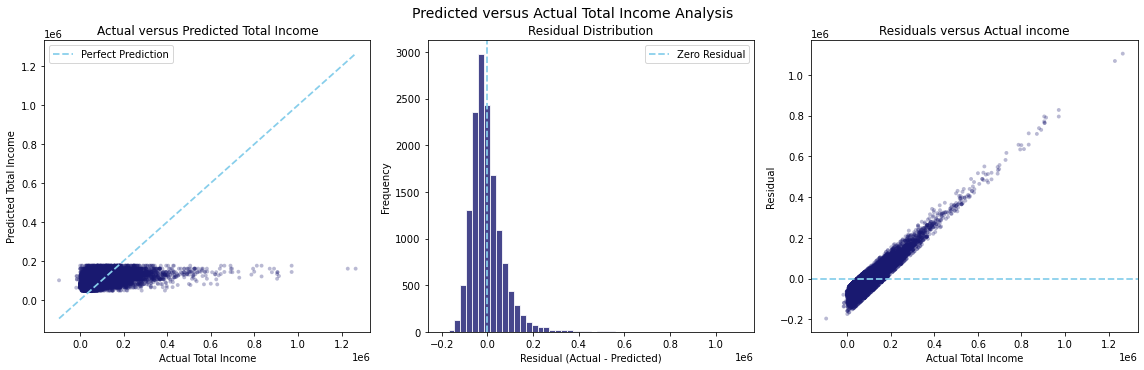


 Prediction Accuracy by Income Percentile:

               mean_actual  mean_predicted  mean_abs_error  median_pct_error
income_bucket                                                               
Bottom 25%        34883.19        94487.41        59657.64            161.07
25 - 50%          74496.55       108067.74        37089.37             45.56
50 - 75%         117408.77       118236.14        21573.68             15.83
Top 25%          217814.69       125005.11        93174.50             36.67


In [215]:
'''
==========================================================================
10 | Final Findings
==========================================================================
'''

# Creating subplots for the actual versus predicted income, the resulting analysis, and the residuals:

print("\n=== Predicted versus Actual Total Income ===")

comparison_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred
})

comparison_df["residual"] = comparison_df["actual"] - comparison_df["predicted"]
comparison_df["abs_error"] = comparison_df["residual"].abs()
comparison_df["pct_error"] = (comparison_df["abs_error"] / comparison_df["actual"].abs()) * 100

print(f"\n Mean Actual Income: {comparison_df['actual'].mean()}")
print(f"\n Mean Predicted Income: {comparison_df['predicted'].mean()}")
print(f"\n Mean Residual: {comparison_df['residual'].mean()}")
print(f"\n Mean Absolute Error: {comparison_df['abs_error'].mean()}")
print(f"\n Median Percentage Error: {comparison_df['pct_error'].median()}")

# Plotting actual versus predicted total income:

fig, axes = plt.subplots(1, 3, figsize = (16, 5))

axes[0].scatter(
    comparison_df["actual"],
    comparison_df["predicted"],
    alpha = 0.3, color = "midnightblue", edgecolors = "none", s = 15
)

min_val = min(comparison_df["actual"].min(), comparison_df["predicted"].min())
max_val = max(comparison_df["actual"].max(), comparison_df["predicted"].max())

axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth = 1.75, color = "skyblue", label = "Perfect Prediction")
axes[0].set_xlabel("Actual Total Income")
axes[0].set_ylabel("Predicted Total Income")
axes[0].set_title("Actual versus Predicted Total Income", fontsize = 12)
axes[0].legend()

# Plotting residual distribution:

axes[1].hist(comparison_df["residual"], bins = 50, color = "midnightblue", edgecolor = "white", alpha = 0.8)
axes[1].axvline(0, color = "skyblue", linestyle = "--", linewidth = 1.75, label = "Zero Residual")
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution", fontsize = 12)
axes[1].legend()

# Plotting residuals versus actuals for a heteroscedasticity (i.e., error variance) check:

axes[2].scatter(
    comparison_df["actual"],
    comparison_df["residual"],
    alpha = 0.3, color = "midnightblue", edgecolor = "none", s = 15
)

axes[2].axhline(0, color = "skyblue", linestyle = "--", linewidth = 1.75)
axes[2].set_xlabel("Actual Total Income")
axes[2].set_ylabel("Residual")
axes[2].set_title("Residuals versus Actual income", fontsize = 12)

plt.suptitle("Predicted versus Actual Total Income Analysis", fontsize = 14, y = 1.02)
plt.tight_layout()
plt.show()

# Creating a summary table of percentile buckets:

comparison_df["income_bucket"] = pd.qcut(
    comparison_df["actual"], q = 4,
    labels = ["Bottom 25%", "25 - 50%", "50 - 75%", "Top 25%"]
)

bucket_summary = comparison_df.groupby("income_bucket", observed = True).agg(
    mean_actual = ("actual", "mean"),
    mean_predicted = ("predicted", "mean"),
    mean_abs_error = ("abs_error", "mean"),
    median_pct_error = ("pct_error", "median")
).round(2)

print("\n Prediction Accuracy by Income Percentile:\n")
print(bucket_summary.to_string())

# Bibliography

Hirapara, A. (2025, March 20). Income survey: Finance analysis. Kaggle. https://www.kaggle.com/datasets/aradhanahirapara/income-survey-finance-analysis 